# Signal and Image Processing (SIP WS25)

### Research Group Neuroinformatics, Faculty of Computer Science,
### University of Vienna


###  DFT & Filtering Tutorial

Lecturer: Prof. Moritz GROSSE-WENTRUP

Tutorial by: 

Sadiq A. ADEDAYO 
$\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad$  Jakob PRAGER 

Kerim ATAK (kerim.atak@univie.ac.at)
$\quad\quad\quad\quad$ Manuel EDER (m.eder@univie.ac.at)

In [1]:
# imports packages required (Numpy and Matplotlib)

import numpy as np
import matplotlib.pyplot as plt

## Discrete Fourier Transform (DFT)

You learned about analysis (DFT) and synthesis (iDFT) from the video lectures. We have introduced that DFT allows us to change the domain of a signal from time to frequency while iDFT does the reverse. 

In this exercise, we will implement this and see how the concept works.

Recall,

Discrete Fourier Transform (Analysis); $$X(k) = \sum_{n=0}^{N-1} x[n] \exp \left( {-j.\frac{ 2\pi k}{N}. n} \right)$$


inverse Discrete Fourier Transform (Synthesis); $$x[n] = \frac{1}{N} \sum_{k=0}^{N-1} X(k) \exp \left( {j.\frac{ 2\pi k}{N}. n} \right)$$

### Trigonometric signals

Before we dive into DFT, it is important to understand the concept of signal oscillations.


Take for instance, a sine signal as defined by;
$$ x[n] = A sin\left( \frac{2 \pi k}{N}. n  \right) $$

where

- A is the amplitude
- k is the frequency of oscillations per second measure in $s^{-1}$ or Hz (assuming, the signal is 1s long).

Intuitively, k is the number of complete periods within N. i.e. if the signal is 1 second long, then k is the frequency.
- N is the signal length. Mathematically; N = $f_{s}$ * T  where $f_{s}$ and `T` are the sampling frequency and length of the signal in [sec] respectively.

$$x[n] = A sin \left(\frac{2 \pi k}{f_{s} T} \cdot n \right)$$

When N = $f_{s}$ * T and T = 1, the formular then becomes;

$$x[n] = A sin \left(\frac{2 \pi k}{f_{s}} \cdot n \right)$$


Oftentimes, Amplitude `A` is not given in the signal equation, this indicates that it is unity (1). Hence

$$x[n] = sin\left( \frac{2 \pi k}{f_{s}} \cdot n  \right)$$

In [2]:
# plot sine signals

def plot_signal(s, label = 's[n]'):
    fig = plt.figure(figsize=(10, 5))
    # if s is array of arrays
    if isinstance(s[0], np.ndarray):
        for (si, li) in zip(s, label):   
            plt.plot(si, label=li)
    else:
        plt.plot(s, label=label)
    plt.grid()
    plt.xlabel('n')
    plt.legend()
    plt.show()

In [3]:
# generate sine signals s1 and s2
# in this case we use 1 second long signal of length N

fs = 1000 # sampling frequency
N = 1 * fs # number of samples
n = np.arange(N) # sample index, n = 0, 1, 2, ..., N-1

k1 = 1  # number of complete periods in N samples
k2 = 50 # number of complete periods in N samples

s1 = np.sin(2 * np.pi * k1 / N * n)
s2 = np.sin(2 * np.pi * k2 / N * n)

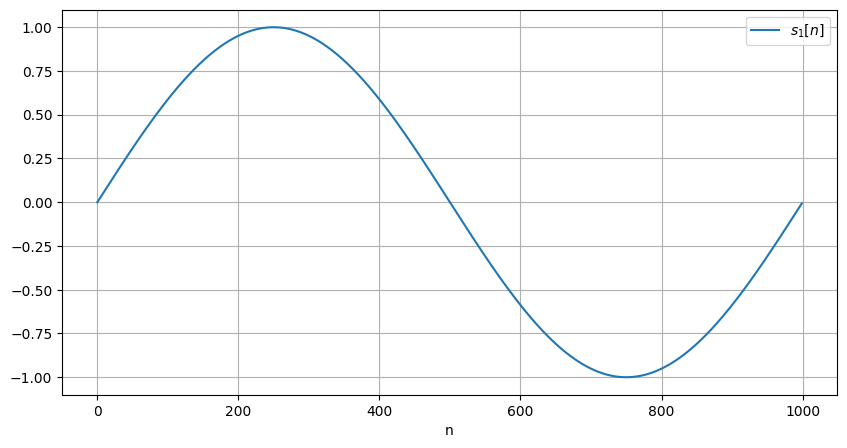

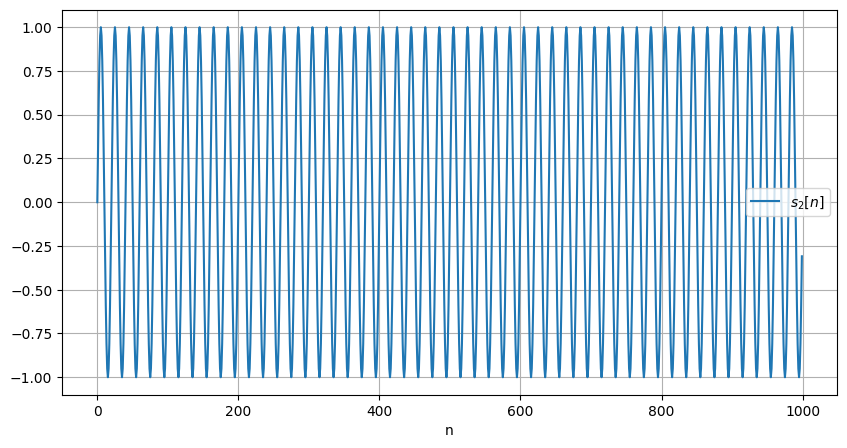

In [4]:
plot_signal(s1, f'$s_{1}[n]$')
plot_signal(s2, f'$s_{2}[n]$')

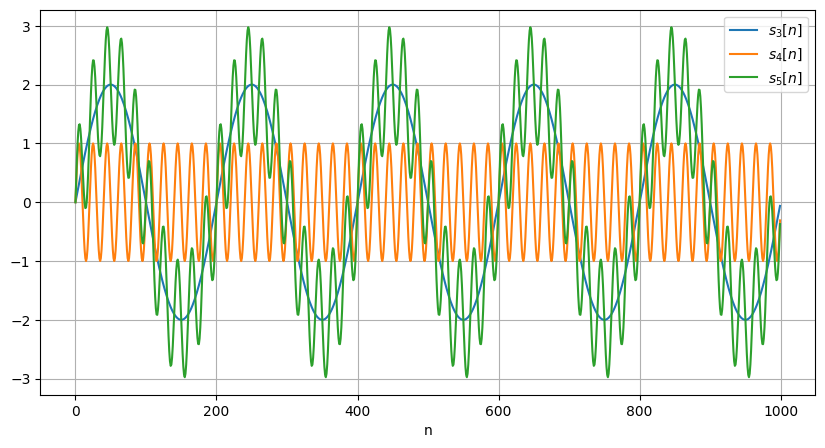

In [5]:
# carry out some operation on signals e.g. addition of two signals for instance
k3, k4 =  5, 50 

s3 = 2 * np.sin(2 * np.pi * k3/N * n)
s4 = np.sin(2 * np.pi * k4/N * n)

# combine the signals
s5 = s3 + s4 

# plot
plot_signal([s3, s4, s5], ['$s_{3}[n]$', '$s_{4}[n]$', '$s_{5}[n]$'])

Here the Amplitudes `A` differ in the mixture of the signals. It can be seen that the amplitudes of the two signals are added together across `n`.

### Implement both DFT and iDFT as functions.

In [6]:
# DFT
def DFT(x):
    """
    input: signal x[n] in time domain
    output: X(f) in frequency domain
    """
    N = len(x)
    
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-1j * 2 * np.pi/N * k * n)
    
    return X

# Alternative:
# def DFT(x):
#     """
#     input: signal x[n] in time domain
#     output: X(f) in frequency domain
#     """
#     N = len(x)
#     n = np.arange(0,N)
#     F = np.exp(-1j * 2 * np.pi/N * np.outer(n, n))   # hint: use np.outer(n,n) for the basis vectors
#     X = np.dot(F, x)
#     return X


# inverse DFT
def iDFT(X):
    """
    input: signal X(f) in frequency domain
    output: x[n] in time domain
    """
    N = len(X)
    x = np.zeros(N, dtype=complex)
    for n in range(N):
        for k in range(N):
            x[n] += X[k] * np.exp(1j * 2 * np.pi/N * k * n)
        x[n] /= N
    return x

# Alternative:
# def iDFT(X):
#     """
#     input: signal X(f) in frequency domain
#     output: x[n] in time domain
#     """
#     N = len(X)
#     n = np.arange(0,N)
#     IF = np.exp(1j* 2* np.pi/N * np.outer(n,n)) /N  # hint: use np.outer(n,n) for the basis vectors
#     return np.dot(IF, X)

In [7]:
# application on signals generated above

S3 = DFT(s3)
S4 = DFT(s4)
S5 = DFT(s5)

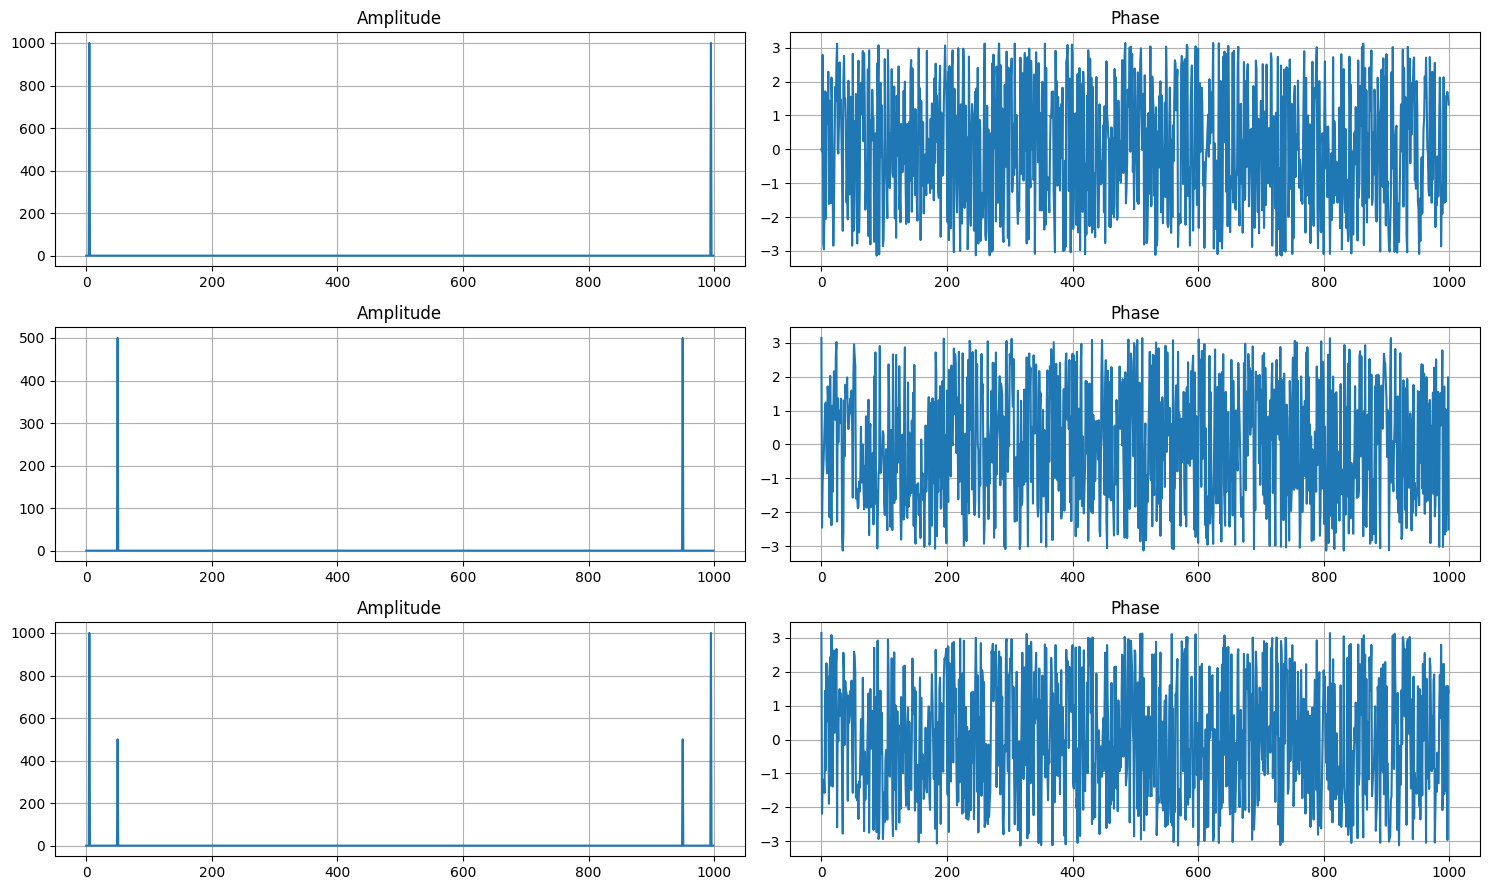

In [8]:
# plots
fig, ax = plt.subplots(3, 2, figsize=(15,9)) # 
ax[0, 0].plot(np.abs(S3))
ax[0, 0].grid()
ax[0, 0].set_title('Amplitude')

ax[0, 1].plot(np.angle(S3))
ax[0, 1].grid()
ax[0, 1].set_title('Phase')


ax[1, 0].plot(np.abs(S4))
ax[1, 0].grid()
ax[1, 0].set_title('Amplitude')

ax[1, 1].plot(np.angle(S4))
ax[1, 1].grid()
ax[1, 1].set_title('Phase')


ax[2, 0].plot(np.abs(S5))
ax[2, 0].grid()
ax[2, 0].set_title('Amplitude')

ax[2, 1].plot(np.angle(S5))
ax[2, 1].grid()
ax[2, 1].set_title('Phase')

plt.tight_layout()

When time domain signal e.g `x[n]`, is converted into frequency domain `X(f)` via DFT, the resulting output is a complex. i.e. it has both amplitude and phase which are two parts of the spectrum of the signal. Oftentimes, signals may have the same amplitude spectrum but a different phase spectrum as in sine and cosine signal.

It is also worth noting, because there are both positive and negative frequencies, the amplitude spectrum is plotted symmetrically and a special function `numpy.fft.fftshift()` should be used. Furthermore, to account for numerical errors, one should set values from the phase plots to 0 where Amplitude < 1e-8.

To obtain the correct frequency axis for plotting the FFT, one can use `freqs = np.fft.fftfreq(N, d=1/fs)`, where `N` is the number of samples and `fs` is the sampling frequency. This function generates the corresponding frequency bins in Hertz that match the FFT output.

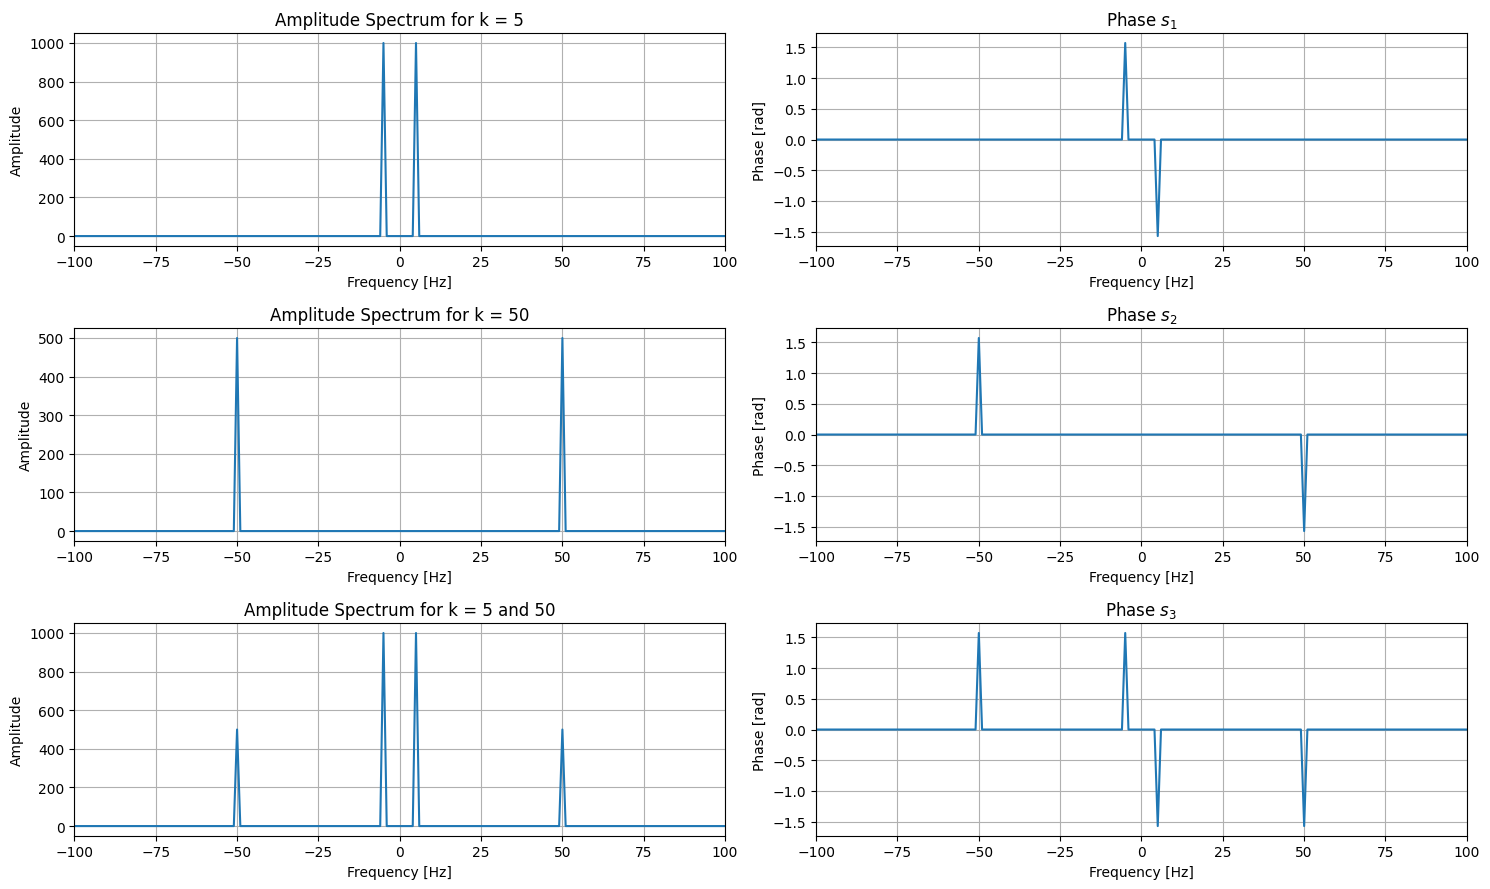

In [9]:
freqs = np.fft.fftfreq(N, d=1/fs)

fig, ax = plt.subplots(3, 2, figsize=(15, 9))

# ---- Row 1: S3 ----
ax[0,0].plot(np.fft.fftshift(freqs), np.fft.fftshift(np.abs(S3)))
ax[0,0].grid()
ax[0,0].set_xlim(-100, 100)
ax[0,0].set_title('Amplitude Spectrum for k = 5')
ax[0,0].set_xlabel('Frequency [Hz]')
ax[0,0].set_ylabel('Amplitude')

phase_S3 = np.angle(S3)
phase_S3[np.abs(S3) < 1e-8] = 0
ax[0,1].plot(np.fft.fftshift(freqs), np.fft.fftshift(phase_S3))
ax[0,1].grid()
ax[0,1].set_xlim(-100, 100)
ax[0,1].set_title('Phase $s_{1}$')
ax[0,1].set_xlabel('Frequency [Hz]')
ax[0,1].set_ylabel('Phase [rad]')

# ---- Row 2: S4 ----
ax[1,0].plot(np.fft.fftshift(freqs), np.fft.fftshift(np.abs(S4)))
ax[1,0].grid()
ax[1,0].set_xlim(-100, 100)
ax[1,0].set_title('Amplitude Spectrum for k = 50')
ax[1,0].set_xlabel('Frequency [Hz]')
ax[1,0].set_ylabel('Amplitude')

phase_S4 = np.angle(S4)
phase_S4[np.abs(S4) < 1e-8] = 0
ax[1,1].plot(np.fft.fftshift(freqs), np.fft.fftshift(phase_S4))
ax[1,1].grid()
ax[1,1].set_xlim(-100, 100)
ax[1,1].set_title('Phase $s_{2}$')
ax[1,1].set_xlabel('Frequency [Hz]')
ax[1,1].set_ylabel('Phase [rad]')

# ---- Row 3: S5 ----
ax[2,0].plot(np.fft.fftshift(freqs), np.fft.fftshift(np.abs(S5)))
ax[2,0].grid()
ax[2,0].set_xlim(-100, 100)
ax[2,0].set_title('Amplitude Spectrum for k = 5 and 50')
ax[2,0].set_xlabel('Frequency [Hz]')
ax[2,0].set_ylabel('Amplitude')

phase_S5 = np.angle(S5)
phase_S5[np.abs(S5) < 1e-8] = 0
ax[2,1].plot(np.fft.fftshift(freqs), np.fft.fftshift(phase_S5))
ax[2,1].grid()
ax[2,1].set_xlim(-100, 100)
ax[2,1].set_title('Phase $s_{3}$')
ax[2,1].set_xlabel('Frequency [Hz]')
ax[2,1].set_ylabel('Phase [rad]')

plt.tight_layout()
plt.show()

One can see that the sine waves all have a phase of pi/2 or -pi/2 (90 degrees). This comes from the mathematical relationship of sine and cosine and how complex exponents are used in the fourier transform. One could calculate this and find out that the only nonzero component of the FFT is where the phase is pi/2 and -pi/2 respectively.

A cosine wave would have phases of 0. As we can write a sine as a cosine shifted by pi/2, this makes sense.

#### We can apply `iDFT()` already implemented above to change back from frequency to time domain.

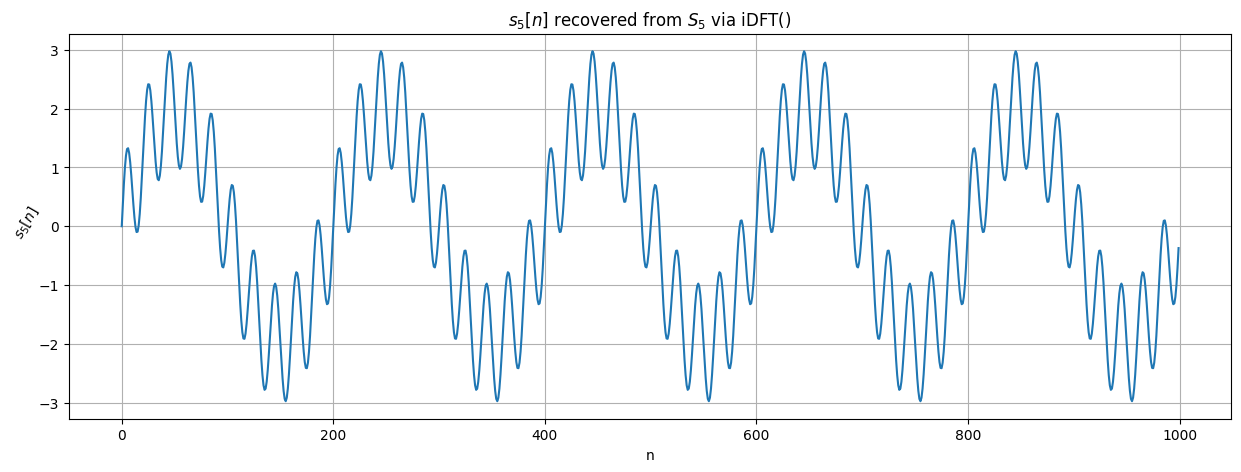

In [10]:
s5_recovered = np.real(iDFT(S5))

# plot

plt.figure(figsize=(15,5))
plt.plot(s5_recovered)
plt.grid()
plt.xlabel('n')
plt.ylabel('$s_{5}[n]$',rotation=60)
plt.title('$s_{5}[n]$ recovered from $S_{5}$ via iDFT()')
plt.show()

### Conclusions

We explored Discrete Fourier Transform (DFT). You are encouraged to look out other use cases to cement your understanding of those concepts. Below are some bonus tasks for your practice.

### Bonus tasks

These tasks are given for more hands-on engagement of students. There will be no solutions or grading (i.e., they are only for students to explore for leisure).


1. Show that the convolution operation fulfills the following properties
 - Commutative i.e., $\quad x[n] * h[n] \quad = \quad h[n] * x[n]$ 

 - Associative i.e., $\quad (x_{1}[n] * h[n]) \quad * x_{2}[n] \quad = \quad x_{1}[n] \quad * (h[n] * x_{2}[n])$
 
 - Derrivative i.e., $\quad y[n] = x[n] * h[n]$
 
 $\quad\quad\quad\quad\quad\quad$ $\frac{dy[n]}{dn} \quad = \quad \frac{dx[n]}{dn} * h[n] \quad = \quad x[n] * \frac{dh[n]}{dn} $.



2. Show that convolution in time domain is same as multiplication in frequency domain
 
 $$x[n] * h[n] = iDFT \left( X[k] . H[k] \right)$$
 
 where `x[n]` and `h[n]` and signal `x` and impulse `h` in time domain
 
     and `X[k]` and `H[k]` are the spectral domain of `x` and `h` respectively.


     
3. Let $x[n] = \sum\limits_{k\in \{10, 50, 100, 150, 200\}} \cos(2\pi \frac{k}{N} .n)$ with $n \in [0, 999]$ and sampling frequency $f_s = 500$Hz. 

> Plot $x[n]$, its frequency spectrum $|X(f)|$, and $\angle X(f)$. 

## Filtering

Now that we have the basics down, we can start manipulating the signal in frequency domain by applying filters directly to the DFT.

An ideal lowpass keeps frequency components with `|f| ≤ fc` and sets everything else to zero. In the frequency domain this is just a rectangular mask (perfect pass/stop). In the time domain the ideal lowpass corresponds to a sinc-shaped impulse response (i.e. non-causal and infinite in duration), so applying an ideal rectangular mask will introduce ringing in time (keep that in mind for practical filters!).

In [11]:
x = s5
X = DFT(x)

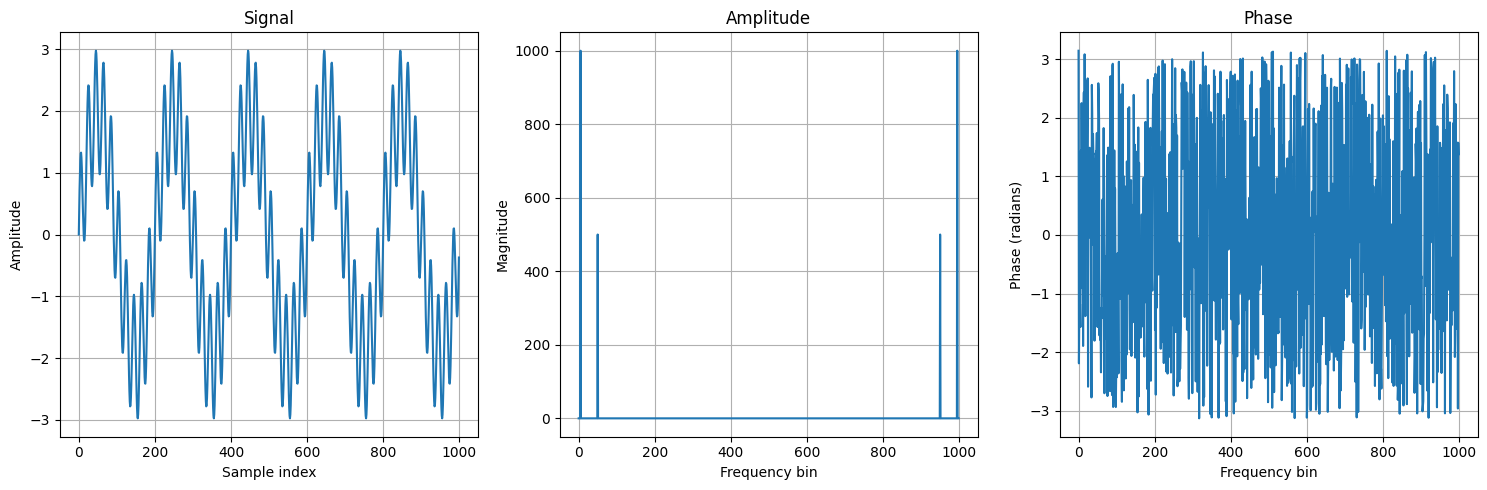

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(x)
ax[0].grid()
ax[0].set_title('Signal')
ax[0].set_xlabel('Sample index')
ax[0].set_ylabel('Amplitude')

ax[1].plot(np.abs(X))
ax[1].grid()
ax[1].set_title('Amplitude')
ax[1].set_xlabel('Frequency bin')
ax[1].set_ylabel('Magnitude')

ax[2].plot(np.angle(X))
ax[2].grid()
ax[2].set_title('Phase')
ax[2].set_xlabel('Frequency bin')
ax[2].set_ylabel('Phase (radians)')

plt.tight_layout()
plt.show()

### Ideal Low-pass filter

### Design a simple filter
Now, given our signal S5 (which consists of sine waves with 5 Hz and 50 Hz added together), you can design an ideal lowpass filter which filters out all frequencies above 5 Hz.

In [13]:
# filter
filter_lp = np.ones(len(X))
filter_lp[6:-6] = 0

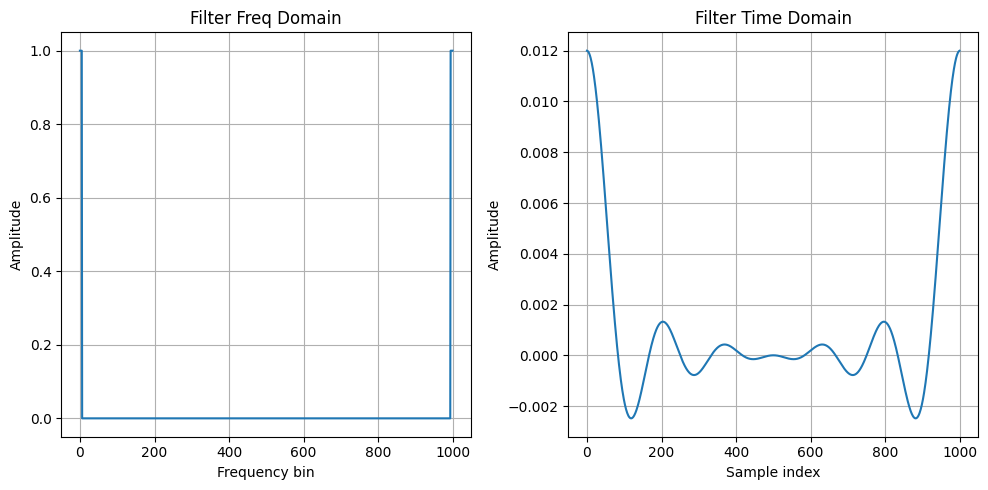

In [14]:
# plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].plot(np.abs(filter_lp))
ax[0].grid()
ax[0].set_title('Filter Freq Domain')
ax[0].set_xlabel('Frequency bin')
ax[0].set_ylabel('Amplitude')

ax[1].plot(np.real(iDFT(filter_lp)))
ax[1].grid()
ax[1].set_title('Filter Time Domain')
ax[1].set_xlabel('Sample index')
ax[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

### Apply your filter in frequency domain

When you apply your frequency-domain mask `filter_lp` to the DFT `X`, you remove the unwanted frequency bins directly. Reconstruct the filtered signal by applying your inverse DFT (`iDFT()`) to the masked spectrum.

In [15]:
# apply filter in frequency domain
X_filtered = X * filter_lp

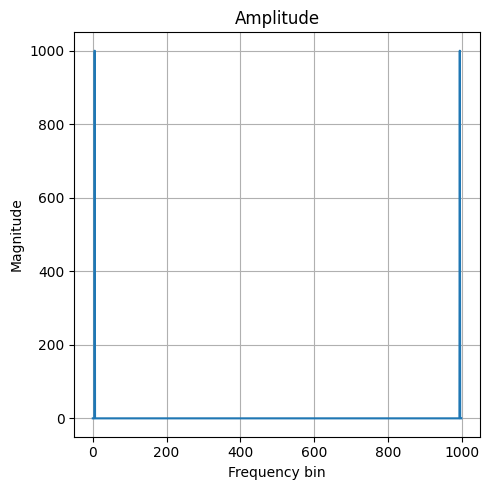

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax.plot(np.abs(X_filtered))
ax.grid()
ax.set_title('Amplitude')
ax.set_xlabel('Frequency bin')
ax.set_ylabel('Magnitude')

plt.tight_layout()
plt.show()

In [17]:
x_filtered_reconstructed = iDFT(X_filtered)

Text(0, 0.5, 'Amplitude')

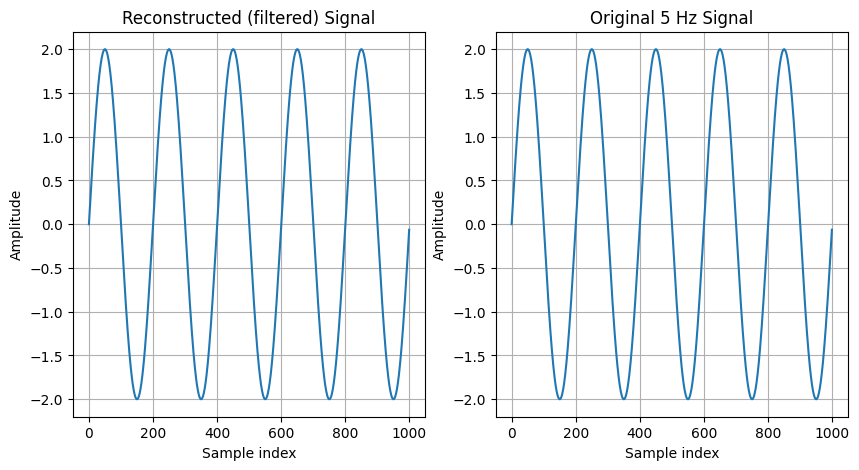

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].plot(np.real(x_filtered_reconstructed))
ax[0].grid()
ax[0].set_title('Reconstructed (filtered) Signal')
ax[0].set_xlabel('Sample index')
ax[0].set_ylabel('Amplitude')

ax[1].plot(s3)
ax[1].grid()
ax[1].set_title('Original 5 Hz Signal')
ax[1].set_xlabel('Sample index')
ax[1].set_ylabel('Amplitude')

## Bonus: Filter design in practice

The ideal filter is great for learning and offline signal experiments. While this is useful to understand the concept, in practice ideal filters are non-causal and infinite in length, which causes ringing (Gibbs phenomenon). In real applications, we use well-designed filters with finite impulse responses (FIR) or infinite impulse responses (IIR).

Python’s `scipy.signal` provides functions to design and apply such filters. We can inspect their frequency responses and see how they behave.

Generally, it is always a good idea to make use of the [documentation](https://docs.scipy.org/doc/scipy/) if you are unsure what certain function parameters do.

### IIR Filters

In [19]:
from scipy.signal import butter, filtfilt, freqz
cutoff = 10  # Hz, note: why does cutoff=5 not work perfectly here?
fs = 1000

# design Butterworth lowpass filter
order = 4
b, a = butter(order, cutoff, fs=fs)

# frequency response
w, h = freqz(b, a, fs=fs)

# apply IIR filter (zero-phase) to s5 using filtfilt
s5_filtered_iir = filtfilt(b, a, s5)

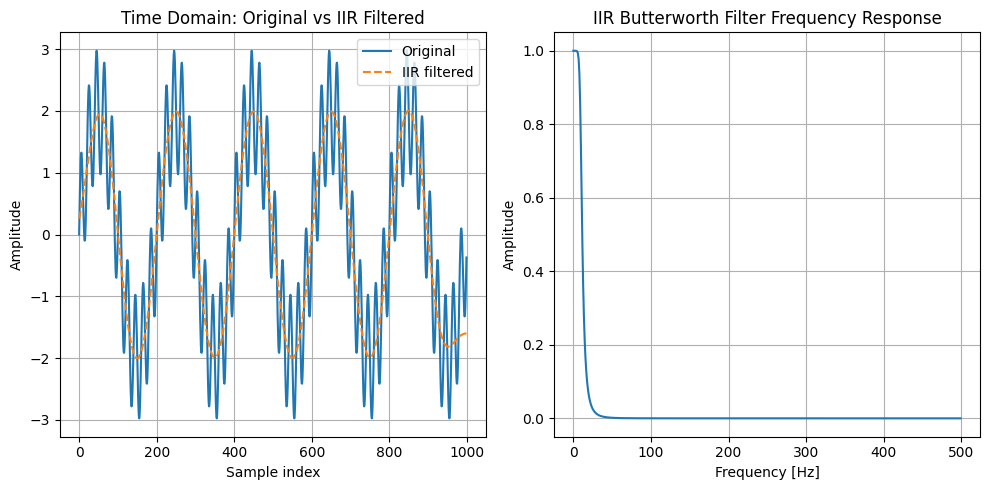

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].plot(s5, label='Original')
ax[0].plot(s5_filtered_iir, '--', label='IIR filtered')
ax[0].set_title('Time Domain: Original vs IIR Filtered')
ax[0].set_xlabel('Sample index')
ax[0].set_ylabel('Amplitude')
ax[0].grid()
ax[0].legend()

ax[1].plot(w, np.abs(h))
ax[1].set_title('IIR Butterworth Filter Frequency Response')
ax[1].set_xlabel('Frequency [Hz]')
ax[1].set_ylabel('Amplitude')
ax[1].grid()

plt.tight_layout()
plt.show()

### FIR filters

In [21]:
from scipy.signal import firwin, lfilter

# filter parameters
fs = 1000         
cutoff = 5  # Hz
numtaps = 100

# FIR lowpass filter using windowed-sinc (Hamming window)
filter_fir = firwin(numtaps, cutoff, fs=fs)

# apply your filter to s5
x_reconstructed_fir = lfilter(filter_fir, 1.0, s5)

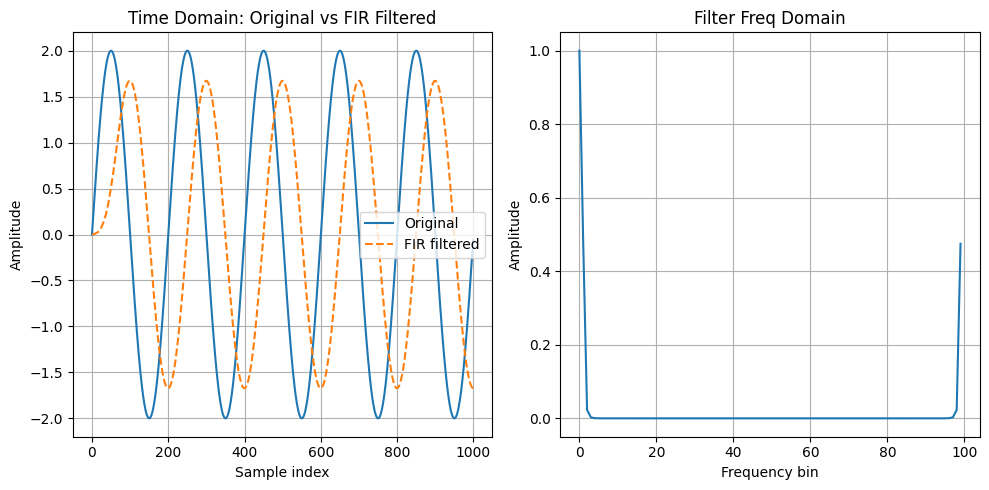

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# time-domain signal
ax[0].plot(s3, label='Original')
ax[0].plot(x_reconstructed_fir, '--', label='FIR filtered')
ax[0].grid()
ax[0].set_title('Time Domain: Original vs FIR Filtered')
ax[0].set_xlabel('Sample index')
ax[0].set_ylabel('Amplitude')
ax[0].legend()

# Frequency-domain magnitude (use DFT)
ax[1].plot(np.abs(DFT(filter_fir))) 
ax[1].grid()
ax[1].set_title('Filter Freq Domain')
ax[1].set_xlabel('Frequency bin')
ax[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()